# Analyze

## Import Packages

In [19]:
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

## Prepare

In [21]:
STORAGE_DIR = "../input"

In [24]:
OUTPUT_DIR = "../output"

In [26]:
DOC_DIR = "../docu"

In [28]:
FILE_DIR = os.path.join(OUTPUT_DIR, "final_merge_df.csv")

In [30]:
final_merge_df = pd.read_csv(os.path.join(FILE_DIR), encoding="utf-8")

## Inspect

### Formatierung der Variable `date` prüfen

In [32]:
final_merge_df.dtypes

Unnamed: 0          int64
id                 object
title              object
preview            object
date               object
zeitschrift        object
analyse_preview    object
analyse_title      object
dtype: object

In [34]:
final_merge_df["date"].count

<bound method Series.count of 0      2026-01-30
1      2026-01-30
2      2026-01-30
3      2026-01-30
4      2026-01-30
          ...    
678    2025-11-30
679    2025-10-30
680    2025-10-30
681    2025-10-14
682    2025-10-14
Name: date, Length: 683, dtype: object>

### Werte der Variablen `analyse_preview` und `analyse_title` prüfen

**analyse_preview**

In [65]:
analyse_preview_df = final_merge_df.groupby("analyse_preview")["id"].count()

In [67]:
analyse_preview_df

analyse_preview
Skepsis      561
Vertrauen    122
Name: id, dtype: int64

<Axes: xlabel='analyse_preview'>

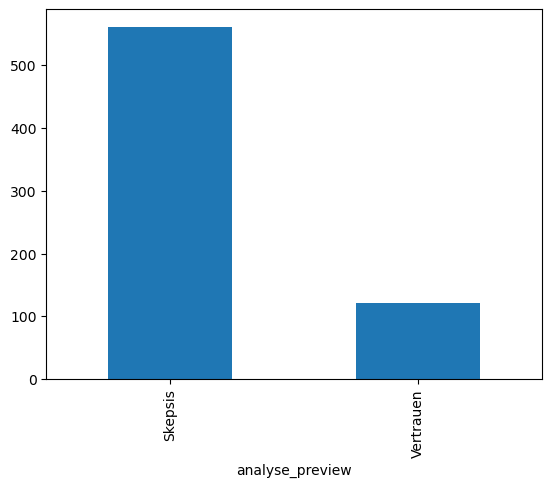

In [69]:
analyse_preview_df.plot.bar()

**analyse_title**

In [61]:
analyse_title_df = final_merge_df.groupby("analyse_title")["id"].count()

In [63]:
analyse_title_df

analyse_title
Skepsis      575
Vertrauen    108
Name: id, dtype: int64

<Axes: xlabel='analyse_title'>

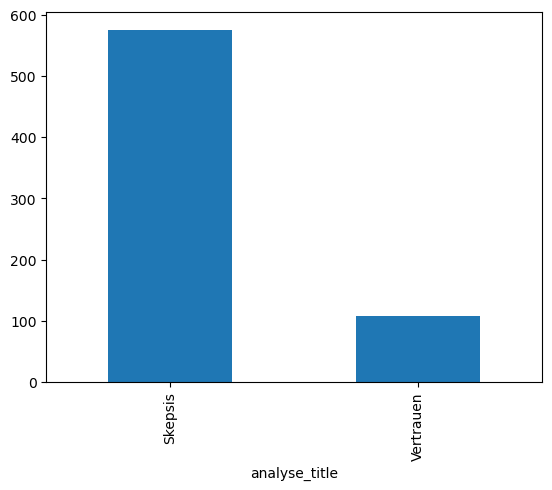

In [71]:
analyse_title_df.plot.bar()

## Transform

### `date`zu datetime umwandeln

In [14]:
final_merge_df["date"] = pd.to_datetime(final_merge_df["date"], dayfirst=True, format="mixed")

### Werte in `analyse_preview` und `analyse_title` vereinheitlichen

In [51]:
final_merge_df["analyse_preview"] = final_merge_df["analyse_preview"].str.replace("SKEPSIS","Skepsis")

In [53]:
final_merge_df["analyse_title"] = final_merge_df["analyse_title"].str.replace("SKEPSIS","Skepsis")

### Datetime to Calenderweek

In [85]:
#Für die X-Achse erstellen wir ein Array mit Daten vom 2025-10-14 bis 2026-01-30
datum = np.arange(np.datetime64("2025-10-14"), np.datetime64("2026-01-30"))

In [243]:
d_developement = final_merge_df.groupby(["date", "analyse_preview"]).size().unstack(fill_value=0)
d_developement_title = final_merge_df.groupby(["date", "analyse_title"]).size().unstack(fill_value=0)

In [245]:
# Wir summieren die Anzahl an `Skepsis` und `Vertrauen` zwischen Titeln und Vorschauen
d_developement["Skepsis"] = d_developement["Skepsis"]+ d_developement_title["Skepsis"]
d_developement["Vertrauen"] = d_developement["Vertrauen"]+ d_developement_title["Vertrauen"]
d_developement

analyse_preview,Skepsis,Vertrauen
date,,
2025-09-05,592,140
2025-10-06,6,2
2025-10-07,5,1
2025-10-08,4,0
2025-10-09,7,3
...,...,...
2026-01-26,3,1
2026-01-27,4,0
2026-01-28,10,0


In [247]:
d_developement.index = pd.to_datetime(d_developement.index)
d_developement = d_developement.reindex(pd.to_datetime(datum), fill_value=0)

In [251]:
d_developement = d_developement.reset_index().rename(columns={"index":"date"})

In [255]:
d_developement["calenderweek"] = d_developement["date"].dt.isocalendar().week
d_developement.head(3)

analyse_preview,date,Skepsis,Vertrauen,calenderweek
0,2025-10-14,10,4,42
1,2025-10-15,4,0,42
2,2025-10-16,6,0,42


In [257]:
d_developement["year"] = d_developement["date"].dt.year
iso_kalender = d_developement["date"].dt.isocalendar()
d_developement["cw_year"] = iso_kalender.week.astype(str) + "_" + iso_kalender.year.astype(str).str[-2:]

## Final Visualisation

### Anzahl an Artikel pro Zeitschrift

<Axes: ylabel='zeitschrift'>

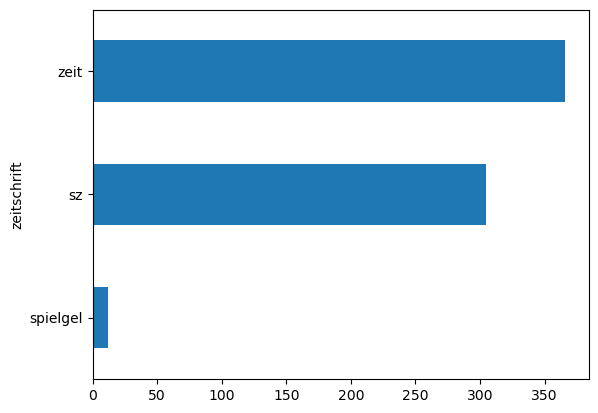

In [116]:
anzahl_artikel = final_merge_df.groupby("zeitschrift")["id"].count()
anzahl_artikel.plot.barh()

### Rel.Häufigkeit: Skepsis vs Vertrauen nach Zeitschrift

**Note**

---

Mithilfe von gestapelten Barplots, ermitteln wir das Verhältnis zwischen Titeln und Vorschau, die entweder mit `Skepsis` oder `Vertrauen` kategorisiert wurden.

---

### Im Titel

In [21]:
###Skepsis
anzahl_skepsis_title = final_merge_df.loc[final_merge_df["analyse_title"] == "Skepsis"]
groupby_skepsis_title = anzahl_skepsis_title.groupby("zeitschrift")["id"].count()

### Vertrauen
anzahl_vertrauen_title = final_merge_df.loc[final_merge_df["analyse_title"] == "Vertrauen"]
groupby_vertrauen_title = anzahl_vertrauen_title.groupby("zeitschrift")["id"].count()

### In der Vorschau

In [24]:
###Skepsis
anzahl_skepsis_preview = final_merge_df.loc[final_merge_df["analyse_preview"] == "Skepsis"]
skepsis = anzahl_skepsis_preview.groupby("zeitschrift")["id"].count()


### Vertrauen
anzahl_vertrauen_preview = final_merge_df.loc[final_merge_df["analyse_preview"] == "Vertrauen"]
vertrauen = anzahl_vertrauen_preview.groupby("zeitschrift")["id"].count()

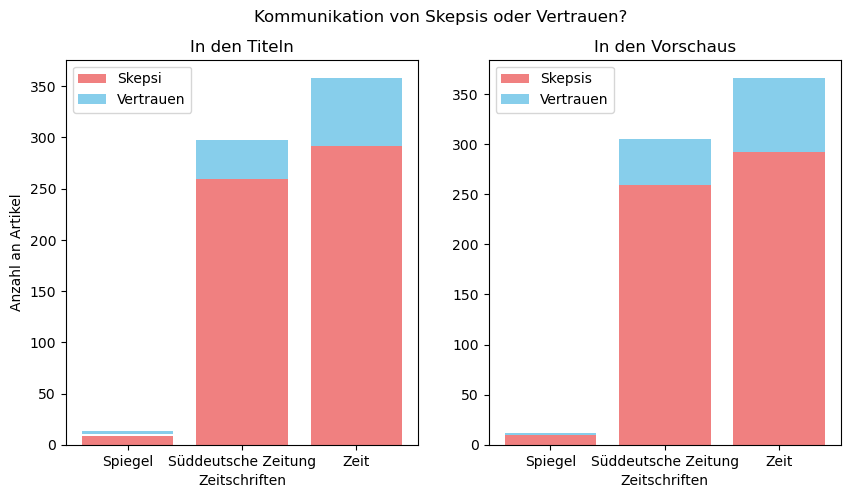

In [28]:
x = ["Spiegel", "Süddeutsche Zeitung", "Zeit"]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))


###1 Axes
ax[0].bar(x, groupby_skepsis_title, label= "Skepsi", color="lightcoral")
ax[0].bar(x, groupby_vertrauen_title, bottom=skepsis, label="Vertrauen", color="skyblue")
ax[0].set_title("In den Titeln")
ax[0].set_xlabel("Zeitschriften")
ax[0].set_ylabel("Anzahl an Artikel")

###2 Axes
ax[1].bar(x, skepsis, label= "Skepsis", color="lightcoral")
ax[1].bar(x, vertrauen, bottom=skepsis, label="Vertrauen", color="skyblue")
ax[1].set_title("In den Vorschaus")
ax[1].set_xlabel("Zeitschriften")


###----Labels
plt.suptitle("Kommunikation von Skepsis oder Vertrauen?")
ax[0].legend()
ax[1].legend()
plt.show()

**Beobachtung:**

---

Es ist bei jeder Zeitschrift deutlich zu erkennen, dass die meisten Artikel, sei es im Titel oder in der Vorschau, zum Thema Friedensverhandlungen zwischen den beiden Parteien mit überwiegend skeptischer Haltung beschrieben werden.

---

### Zeitliche Entwicklung: Skepsis vs Vertrauen

**Note**

---

Zuletzt wollen wir unsere Analyse in einem zeitlichen Verlauf veranschaulichen. Wir zeichnen in einem Liniendiagramm den Verlauf der Anzahl an Titeln und Vorschauen mit den Kategorien `Skepsis` oder `Vertrauen` über den Zeitraum vom Tag der Verkündung der Friedensverhandlungen bis zu dem Tag, an dem die Daten erhoben wurden (`2026-01-30` - `2025-10-14`)

---

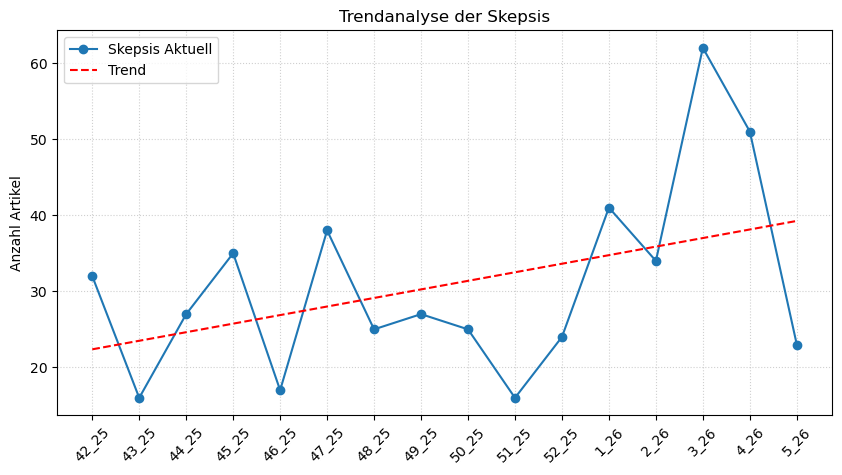

In [259]:
d_plot = d_developement.groupby("cw_year", sort=False)[["Skepsis", "Vertrauen"]].sum().reset_index()

y_skepsis = d_plot["Skepsis"].astype(float).values
x_num = np.arange(len(y_skepsis)).astype(float)

z = np.polyfit(x_num, y_skepsis, 1)
p = np.poly1d(z)


fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(d_plot["cw_year"], y_skepsis, label="Skepsis Aktuell", marker="o")


ax.plot(d_plot["cw_year"], p(x_num), "r--", label="Trend")

# Formatierung
plt.xticks(rotation=45)
plt.title("Trendanalyse der Skepsis")
plt.ylabel("Anzahl Artikel")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

**Beobachtung:**

---

Im zeitlichen Verlauf können wir einen Aufwärtstrend hinsichtlich Artikeln (Titel, Vorschau) zur Thematik der Friedensverhandlungen mit Skepsis beurteilen. 

---

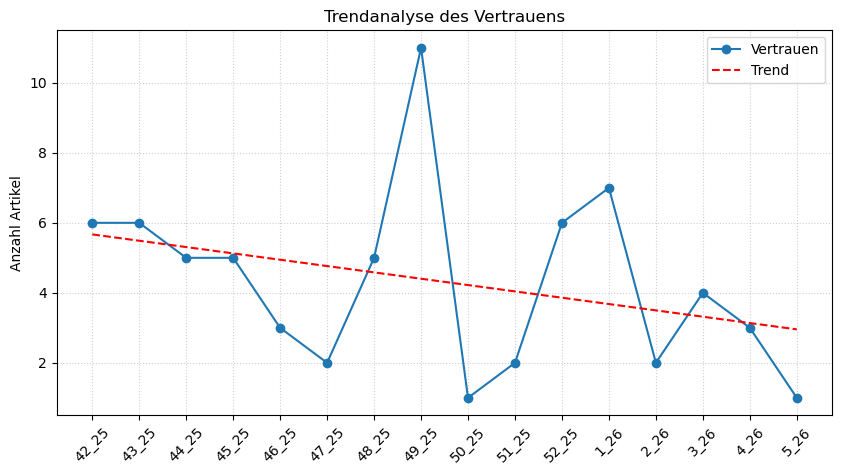

In [261]:
d_plot = d_developement.groupby("cw_year", sort=False)[["Skepsis", "Vertrauen"]].sum().reset_index()

y_skepsis = d_plot["Vertrauen"].astype(float).values
x_num = np.arange(len(y_skepsis)).astype(float)

z = np.polyfit(x_num, y_skepsis, 1)
p = np.poly1d(z)

# 4. Plotten
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(d_plot["cw_year"], y_skepsis, label="Vertrauen", marker="o")

ax.plot(d_plot["cw_year"], p(x_num), "r--", label="Trend")

# Formatierung
plt.xticks(rotation=45)
plt.title("Trendanalyse des Vertrauens")
plt.ylabel("Anzahl Artikel")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

**Beobachtung:**

---

Im zeitlichen Verlauf können wir einen Abwärtstrend hinsichtlich Artikeln (Titel, Vorschau) zur Thematik der Friedensverhandlungen mit Vertrauen beurteilen. 

---